In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from pathlib import Path

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    silhouette_samples
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

## Data Overview

In [6]:
df = pd.read_csv("data/feature_engineered_data.csv")

In [7]:
print(f"\n📊 DATA SUMMARY:")
print(f"  • Countries: {df['country_name'].nunique()}")
print(f"  • Indicators: {df['indicator_name'].nunique()}")
print(f"  • Year range: {df['year'].min()} - {df['year'].max()}")
print(f"  • Regions: {df['region'].unique().tolist()}")


📊 DATA SUMMARY:
  • Countries: 18
  • Indicators: 42
  • Year range: 2000 - 2023
  • Regions: ['North Africa', 'GCC', 'Other', 'Levant']


In [8]:
df.isna().sum()

country_name                  0
year                          0
value                         0
indicator_id                  0
indicator_name                0
unit_type                     0
source                        0
source_reliable               0
region                        0
category                      0
val_num                       0
yoy_change                  756
yoy_pct_change            11215
yoy_pct_exists                0
rolling_mean_3y               0
rolling_std_3y             6966
rolling_mean_5y               0
rolling_std_5y             6966
cagr                       8295
spike                         0
dip                           0
outlier                       0
trend_slope                   0
coef_variation             3144
momentum                   5643
regional_deviation            0
regional_deviation_std        0
event_global               3024
event_country             15582
dtype: int64

In [9]:
base_cols = ['country_name', 'year', 'indicator_name', 'value', 'region', 'category','unit_type']
engineered_features = [col for col in df.columns if col not in base_cols]
    
print(f"\n🔧 ENGINEERED FEATURES DETECTED: {len(engineered_features)}")


🔧 ENGINEERED FEATURES DETECTED: 22


In [10]:
# Group by feature type
temporal_features = [f for f in engineered_features if any(
        x in f for x in ['yoy', 'rolling', 'growth', 'cagr']
    )]
shock_features = [f for f in engineered_features if any(
        x in f for x in ['spike', 'dip', 'outlier']
    )]
stability_features = [f for f in engineered_features if any(
        x in f for x in ['trend', 'slope', 'coef', 'momentum']
    )]
contextual_features = [f for f in engineered_features if any(
        x in f for x in ['regional', 'deviation']
    )]
    
print(f"\n  Temporal features ({len(temporal_features)}):")
for f in temporal_features[:20]:  # Show first 5
        print(f"    • {f}")

    
print(f"\n  Shock features ({len(shock_features)}):")
for f in shock_features:
        print(f"    • {f}")
    
print(f"\n  Stability features ({len(stability_features)}):")
for f in stability_features:
        print(f"    • {f}")
    
print(f"\n  Contextual features ({len(contextual_features)}):")
for f in contextual_features:
        print(f"    • {f}")
    



  Temporal features (8):
    • yoy_change
    • yoy_pct_change
    • yoy_pct_exists
    • rolling_mean_3y
    • rolling_std_3y
    • rolling_mean_5y
    • rolling_std_5y
    • cagr

  Shock features (3):
    • spike
    • dip
    • outlier

  Stability features (3):
    • trend_slope
    • coef_variation
    • momentum

  Contextual features (2):
    • regional_deviation
    • regional_deviation_std


## Data Prep for ML

In [11]:
w_df = (
    df
    .pivot_table(
        index=['country_name', 'year'],      # rows: country + year
        columns='indicator_name',           # columns: one per indicator
        values='val_num',                   # values: numeric indicator
        aggfunc='first'                     # if duplicates exist, take first
    )
)

# Make indicator names regular columns instead of MultiIndex
w_df = w_df.reset_index()

print(w_df.shape)
print("Countries:", w_df['country_name'].nunique())
print("Years:", w_df['year'].min(), "→", w_df['year'].max())


(432, 44)
Countries: 18
Years: 2000 → 2023


In [12]:
w_df.head()

indicator_name,country_name,year,A woman can apply for a passport in the same way as a man (1=yes; 0=no),"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)",A woman can choose where to live in the same way as a man (1=yes; 0=no),A woman can get a job in the same way as a man (1=yes; 0=no),A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no),A woman can open a bank account in the same way as a man (1=yes; 0=no),A woman can register a business in the same way as a man (1=yes; 0=no),A woman can sign a contract in the same way as a man (1=yes; 0=no),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Women Business and the Law Index Score (scale 1-100),"Women, Business and the Law: Assets Indicator Score (scale 1-100)","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)","Women, Business and the Law: Marriage Indicator Score (scale 1-100)","Women, Business and the Law: Mobility Indicator Score (scale 1-100)","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)","Women, Business and the Law: Pay Indicator Score (scale 1-100)","Women, Business and the Law: Pension Indicator Score (scale 1-100)","Women, Business and the Law: Workplace Indicator Score (scale 1-100)"
0,Algeria,2000,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,30.230035,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
1,Algeria,2001,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,30.227092,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
2,Algeria,2002,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,29.498284,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
3,Algeria,2003,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,28.639370,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
4,Algeria,2004,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,28.189026,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0


### Country-level profiles (one row per country)

In [13]:
# Example: focus on SDG / post-Arab-Spring period
wide_focus = w_df[w_df['year'] >= 2010].copy()


In [14]:
# drop non-numeric columns for aggregation
indicator_cols = wide_focus.columns.difference(['country_name', 'year'])

# mean over time
country_mean = (
    wide_focus
    .groupby('country_name')[indicator_cols]
    .mean()
)

# add suffix to remember this is mean
country_mean = country_mean.add_suffix('_mean')

country_mean.head()


indicator_name,A woman can apply for a passport in the same way as a man (1=yes; 0=no)_mean,"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)_mean",A woman can choose where to live in the same way as a man (1=yes; 0=no)_mean,A woman can get a job in the same way as a man (1=yes; 0=no)_mean,A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)_mean,A woman can open a bank account in the same way as a man (1=yes; 0=no)_mean,A woman can register a business in the same way as a man (1=yes; 0=no)_mean,A woman can sign a contract in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside her home in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside the country in the same way as a man (1=yes; 0=no)_mean,...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)_mean",Women Business and the Law Index Score (scale 1-100)_mean,"Women, Business and the Law: Assets Indicator Score (scale 1-100)_mean","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_mean","Women, Business and the Law: Marriage Indicator Score (scale 1-100)_mean","Women, Business and the Law: Mobility Indicator Score (scale 1-100)_mean","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_mean","Women, Business and the Law: Pay Indicator Score (scale 1-100)_mean","Women, Business and the Law: Pension Indicator Score (scale 1-100)_mean","Women, Business and the Law: Workplace Indicator Score (scale 1-100)_mean"
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.000000,1.000000,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,28.289890,56.428571,40.0,75.000000,51.428571,75.000000,60.000000,50.000000,25.000000,75.000000
Bahrain,1.000000,0.428571,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.030670,44.196429,40.0,82.142857,20.000000,50.000000,40.000000,23.214286,60.714286,37.500000
"Egypt, Arab Rep.",0.000000,0.000000,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,19.163498,43.973214,40.0,80.357143,4.285714,50.000000,20.000000,0.000000,100.000000,57.142857
"Iran, Islamic Rep.",0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,39.760180,30.535714,40.0,75.000000,0.000000,0.000000,54.285714,50.000000,25.000000,0.000000
Iraq,0.571429,0.000000,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,26.311310,40.357143,40.0,78.571429,0.000000,14.285714,11.428571,39.285714,60.714286,78.571429


In [15]:
# sort so last() is really last year
wide_focus = wide_focus.sort_values(['country_name', 'year'])

country_last = (
    wide_focus
    .groupby('country_name')[indicator_cols]
    .last()
)

country_last = country_last.add_suffix('_last')

country_last.head()


indicator_name,A woman can apply for a passport in the same way as a man (1=yes; 0=no)_last,"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)_last",A woman can choose where to live in the same way as a man (1=yes; 0=no)_last,A woman can get a job in the same way as a man (1=yes; 0=no)_last,A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)_last,A woman can open a bank account in the same way as a man (1=yes; 0=no)_last,A woman can register a business in the same way as a man (1=yes; 0=no)_last,A woman can sign a contract in the same way as a man (1=yes; 0=no)_last,A woman can travel outside her home in the same way as a man (1=yes; 0=no)_last,A woman can travel outside the country in the same way as a man (1=yes; 0=no)_last,...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)_last",Women Business and the Law Index Score (scale 1-100)_last,"Women, Business and the Law: Assets Indicator Score (scale 1-100)_last","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_last","Women, Business and the Law: Marriage Indicator Score (scale 1-100)_last","Women, Business and the Law: Mobility Indicator Score (scale 1-100)_last","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_last","Women, Business and the Law: Pay Indicator Score (scale 1-100)_last","Women, Business and the Law: Pension Indicator Score (scale 1-100)_last","Women, Business and the Law: Workplace Indicator Score (scale 1-100)_last"
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,28.236443,57.500,40.0,75.0,60.0,75.0,60.0,50.0,25.0,75.0
Bahrain,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.007825,68.125,40.0,100.0,40.0,50.0,40.0,100.0,100.0,75.0
"Egypt, Arab Rep.",0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,22.671914,50.625,40.0,100.0,20.0,50.0,20.0,0.0,100.0,75.0
"Iran, Islamic Rep.",0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,39.773023,31.250,40.0,75.0,0.0,0.0,60.0,50.0,25.0,0.0
Iraq,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,26.009439,48.125,40.0,100.0,0.0,25.0,20.0,50.0,50.0,100.0


In [16]:
country_std = (
    wide_focus
    .groupby('country_name')[indicator_cols]
    .std()
)
country_std = country_std.add_suffix('_std')


In [17]:
# Start with mean
country_profiles = country_mean.join(country_last, how='inner')

# If you want std too:
country_profiles = country_profiles.join(country_std, how='inner')

# Add region metadata (from original long df)
region_map = (
    df[['country_name', 'region']]
    .drop_duplicates()
    .set_index('country_name')
)

country_profiles = country_profiles.join(region_map, how='left')

country_profiles.head()
print(country_profiles.shape)


(18, 127)


In [18]:
country_profiles.head()

,A woman can apply for a passport in the same way as a man (1=yes; 0=no)_mean,"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)_mean",A woman can choose where to live in the same way as a man (1=yes; 0=no)_mean,A woman can get a job in the same way as a man (1=yes; 0=no)_mean,A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)_mean,A woman can open a bank account in the same way as a man (1=yes; 0=no)_mean,A woman can register a business in the same way as a man (1=yes; 0=no)_mean,A woman can sign a contract in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside her home in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside the country in the same way as a man (1=yes; 0=no)_mean,...,Women Business and the Law Index Score (scale 1-100)_std,"Women, Business and the Law: Assets Indicator Score (scale 1-100)_std","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_std","Women, Business and the Law: Marriage Indicator Score (scale 1-100)_std","Women, Business and the Law: Mobility Indicator Score (scale 1-100)_std","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_std","Women, Business and the Law: Pay Indicator Score (scale 1-100)_std","Women, Business and the Law: Pension Indicator Score (scale 1-100)_std","Women, Business and the Law: Workplace Indicator Score (scale 1-100)_std",region
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.000000,1.000000,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.283881,0.0,0.000000,10.271052,0.000000,0.000000,0.000000,0.000000,0.000000,North Africa
Bahrain,1.000000,0.428571,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,13.948369,0.0,11.720181,19.215378,0.000000,0.000000,42.135639,18.898224,30.618622,GCC
"Egypt, Arab Rep.",0.000000,0.000000,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,4.603296,0.0,10.645383,8.516306,0.000000,0.000000,0.000000,0.000000,24.862258,North Africa
"Iran, Islamic Rep.",0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.172018,0.0,0.000000,0.000000,0.000000,9.376145,0.000000,0.000000,0.000000,Other
Iraq,0.571429,0.000000,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,6.585761,0.0,9.078413,0.000000,12.838815,10.271052,12.838815,12.838815,25.677630,Other


In [19]:
# How much missingness is left?
print(country_profiles.isna().mean().sort_values(ascending=False))



A woman can apply for a passport in the same way as a man (1=yes; 0=no)_mean         0.0
Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_last           0.0
A woman can travel outside the country in the same way as a man (1=yes; 0=no)_std    0.0
A woman can travel outside her home in the same way as a man (1=yes; 0=no)_std       0.0
A woman can sign a contract in the same way as a man (1=yes; 0=no)_std               0.0
                                                                                    ... 
Women, Business and the Law: Mobility Indicator Score (scale 1-100)_mean             0.0
Women, Business and the Law: Marriage Indicator Score (scale 1-100)_mean             0.0
Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_mean     0.0
Women, Business and the Law: Assets Indicator Score (scale 1-100)_mean               0.0
region                                                                               0.0
Length: 127, dtype: f

In [20]:
null_cols = country_profiles.columns[country_profiles.isna().any()].tolist()
null_cols

[]

## EXPLORATORY DATA ANALYSIS (EDA)

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

#### Correlation Matrix (Top 30 Indicators)

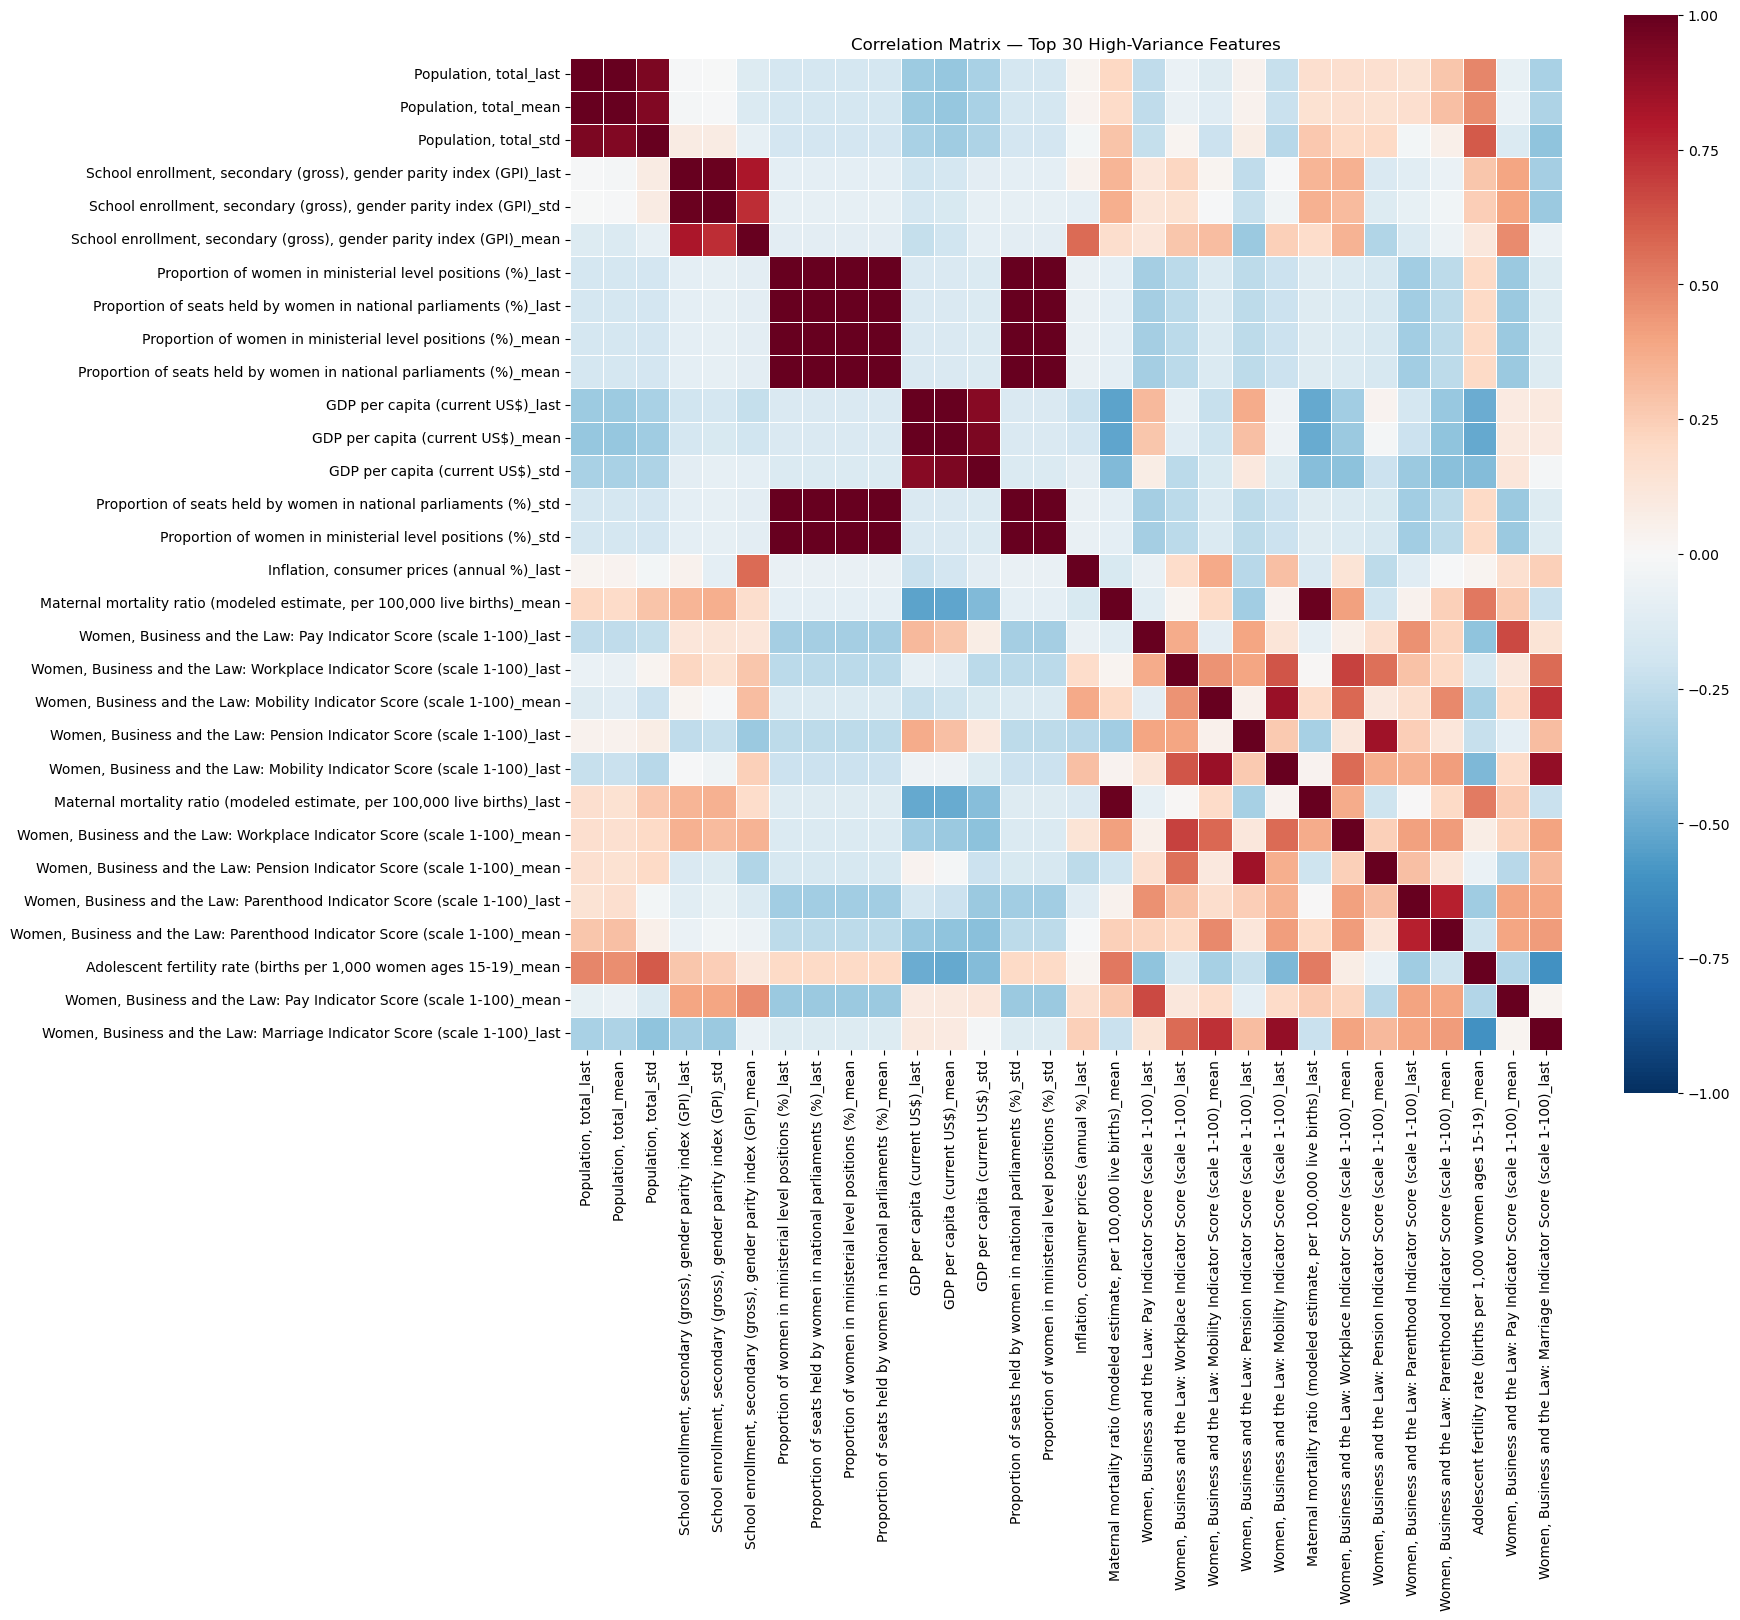

In [22]:
# numeric features only
numeric_cols = country_profiles.select_dtypes(include=[np.number]).columns

# select top 30 by variance — avoids clutter
top_features = country_profiles[numeric_cols].var().nlargest(30).index

corr = country_profiles[top_features].corr()

plt.figure(figsize=(16,14))
#mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)

plt.title("Correlation Matrix — Top 30 High-Variance Features")
plt.show()

In [23]:
country_profiles[numeric_cols].var().nlargest(50)

Population, total_last                                                                9.988605e+14
Population, total_mean                                                                8.158382e+14
Population, total_std                                                                 4.555975e+12
School enrollment, secondary (gross), gender parity index (GPI)_last                  1.602812e+11
School enrollment, secondary (gross), gender parity index (GPI)_std                   2.333761e+10
School enrollment, secondary (gross), gender parity index (GPI)_mean                  7.379776e+09
Proportion of women in ministerial level positions (%)_last                           4.368184e+09
Proportion of seats held by women in national parliaments (%)_last                    4.368156e+09
Proportion of women in ministerial level positions (%)_mean                           3.443474e+09
Proportion of seats held by women in national parliaments (%)_mean                    3.443379e+09
GDP per ca

In [24]:
# 1. List of features to KEEP for ML
ml_features = [
    'Population, total_mean',
    'GDP per capita (current US$)_mean',
    'School enrollment, secondary (gross), gender parity index (GPI)_mean',
    'Proportion of seats held by women in national parliaments (%)_mean',
    'Women Business and the Law Index Score (scale 1-100)_mean',
    'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
    'Inflation, consumer prices (annual %)_mean',
    'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean'
    #'region',   # keep for later visualization but not for PCA
    #'country_name'   # optional, depending on your index
]

# 2. Subset your ML dataset
ml_df = country_profiles[ml_features].copy()

ml_df.head()


,"Population, total_mean",GDP per capita (current US$)_mean,"School enrollment, secondary (gross), gender parity index (GPI)_mean",Proportion of seats held by women in national parliaments (%)_mean,Women Business and the Law Index Score (scale 1-100)_mean,"Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean","Adolescent fertility rate (births per 1,000 women ages 15-19)_mean","Inflation, consumer prices (annual %)_mean","Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean"
country_name,,,,,,,,,
Algeria,4.122578e+07,4991.221498,1.038538,21.485630,56.428571,77.857143,9.756929,5.337271,11.726714
Bahrain,1.397187e+06,25991.901821,1.040759,11.607143,44.196429,14.857143,12.226643,1.271203,41.151929
"Egypt, Arab Rep.",1.022794e+08,3117.834388,0.986903,15.138855,43.973214,26.142857,50.559214,13.004708,15.489214
"Iran, Islamic Rep.",8.414512e+07,5369.001800,0.959292,4.559862,30.535714,24.785714,32.936214,26.042604,11.937571
Iraq,3.856081e+07,5436.911634,198240.020355,26.306004,40.357143,83.357143,72.327214,1.444095,9.307714


## PRINCIPAL COMPONENT ANALYSIS - PCA

In [25]:
# Keep a copy of your metadata
meta_cols = []
if "region" in ml_df.columns:
    meta_cols.append("region")

ml_features = [col for col in ml_features if col in ml_df.columns]
ml_features

['Population, total_mean',
 'GDP per capita (current US$)_mean',
 'School enrollment, secondary (gross), gender parity index (GPI)_mean',
 'Proportion of seats held by women in national parliaments (%)_mean',
 'Women Business and the Law Index Score (scale 1-100)_mean',
 'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
 'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
 'Inflation, consumer prices (annual %)_mean',
 'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean']

In [26]:
ml_df.columns

Index(['Population, total_mean', 'GDP per capita (current US$)_mean',
       'School enrollment, secondary (gross), gender parity index (GPI)_mean',
       'Proportion of seats held by women in national parliaments (%)_mean',
       'Women Business and the Law Index Score (scale 1-100)_mean',
       'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
       'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
       'Inflation, consumer prices (annual %)_mean',
       'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean'],
      dtype='object')

#### Scaling different unit types

In [27]:

X = ml_df[ml_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("Mean (should be ~0):", np.round(X_scaled.mean(), 4))
print("Std (should be ~1):", np.round(X_scaled.std(), 4))


Scaled shape: (18, 9)
Mean (should be ~0): 0.0
Std (should be ~1): 1.0


#### Find how many PCs we need (variance threshold)

In [28]:
# Fit PCA with all possible components (max = number of features)
n_features = X_scaled.shape[1]
pca_full = PCA(n_components=n_features)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

for i, (ev, cv) in enumerate(zip(explained, cumulative), start=1):
    print(f"PC{i}: {ev:.3f}  |  Cumulative: {cv:.3f}")


PC1: 0.362  |  Cumulative: 0.362
PC2: 0.186  |  Cumulative: 0.548
PC3: 0.141  |  Cumulative: 0.689
PC4: 0.123  |  Cumulative: 0.812
PC5: 0.092  |  Cumulative: 0.905
PC6: 0.044  |  Cumulative: 0.949
PC7: 0.026  |  Cumulative: 0.974
PC8: 0.018  |  Cumulative: 0.992
PC9: 0.008  |  Cumulative: 1.000


In [29]:
variance_threshold = 0.95
optimal_n = np.argmax(cumulative >= variance_threshold) + 1

print("\nOptimal components:", optimal_n)
print("Total variance explained:", cumulative[optimal_n - 1])
print("Dimensionality reduction:", n_features, "→", optimal_n)



Optimal components: 7
Total variance explained: 0.9744320262747498
Dimensionality reduction: 9 → 7


In [35]:
pca = PCA(n_components=optimal_n)
X_pca = pca.fit_transform(X_scaled)

pc_cols = [f"PC{i+1}" for i in range(optimal_n)]

# Build PCA dataframe with countries as index
pca_df = pd.DataFrame(X_pca, index=ml_df.index, columns=pc_cols)

# Add metadata for later plots
for col in meta_cols:
    pca_df[col] = ml_df[col]

pca_df.head()

np.save("X_pca.npy", X_pca)


In [44]:
region_lookup = df[["country_name", "region"]].drop_duplicates()

ml_df = ml_df.merge(region_lookup, on="country_name", how="left")


In [45]:
ml_df.columns.tolist()


['country_name',
 'Population, total_mean',
 'GDP per capita (current US$)_mean',
 'School enrollment, secondary (gross), gender parity index (GPI)_mean',
 'Proportion of seats held by women in national parliaments (%)_mean',
 'Women Business and the Law Index Score (scale 1-100)_mean',
 'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
 'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
 'Inflation, consumer prices (annual %)_mean',
 'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean',
 'region']

In [46]:
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pc_cols)
pca_df["country_name"] = ml_df.index
pca_df["region"] = ml_df["region"]

pca_df.to_csv("data/pca_df.csv", index=False)


In [38]:

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance:", explained[:5])
print("Cumulative:", cumulative[:5])


Explained variance: [0.36152198 0.18636491 0.14101196 0.12349026 0.09219664]
Cumulative: [0.36152198 0.54788689 0.68889885 0.81238911 0.90458575]


In [39]:
X_pca_5 = X_pca[:, :5]   # first 5 components
np.save("X_pca_5.npy", X_pca_5)


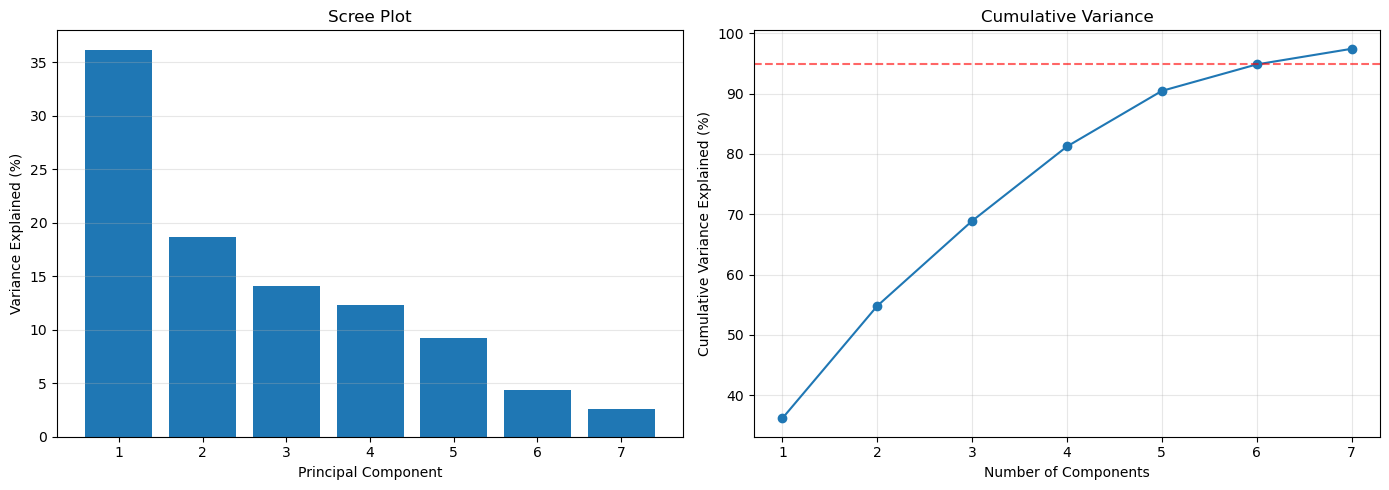

In [31]:
variance_ratio = pca.explained_variance_ratio_
cumulative = np.cumsum(variance_ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of individual variance
x = np.arange(1, len(variance_ratio) + 1)
ax1.bar(x, variance_ratio * 100)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Scree Plot")
ax1.grid(axis="y", alpha=0.3)

# Cumulative line plot
ax2.plot(x, cumulative * 100, marker="o")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained (%)")
ax2.set_title("Cumulative Variance")
ax2.axhline(95, color="red", linestyle="--", alpha=0.6)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
loadings = pca.components_   # shape = (n_components, n_features)
feature_names = ml_features

for pc_idx in range(min(3, optimal_n)):   # inspect first 3 PCs
    pc_loadings = loadings[pc_idx, :]
    series = pd.Series(pc_loadings, index=feature_names)
    
    print(f"\n=== PC{pc_idx+1} (variance: {pca.explained_variance_ratio_[pc_idx]:.2%}) ===")
    print("Top positive loadings (features that increase this PC):")
    print(series.sort_values(ascending=False).head(5))
    
    print("\nTop negative loadings (features that decrease this PC):")
    print(series.sort_values(ascending=True).head(5))



=== PC1 (variance: 36.15%) ===
Top positive loadings (features that increase this PC):
Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean    0.513562
GDP per capita (current US$)_mean                                              0.493370
Proportion of seats held by women in national parliaments (%)_mean            -0.046530
Women Business and the Law Index Score (scale 1-100)_mean                     -0.062898
School enrollment, secondary (gross), gender parity index (GPI)_mean          -0.140605
dtype: float64

Top negative loadings (features that decrease this PC):
Adolescent fertility rate (births per 1,000 women ages 15-19)_mean          -0.431192
Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean   -0.374747
Population, total_mean                                                      -0.320440
Inflation, consumer prices (annual %)_mean                                  -0.194693
School enrollment, secondary (gross), gender parity inde

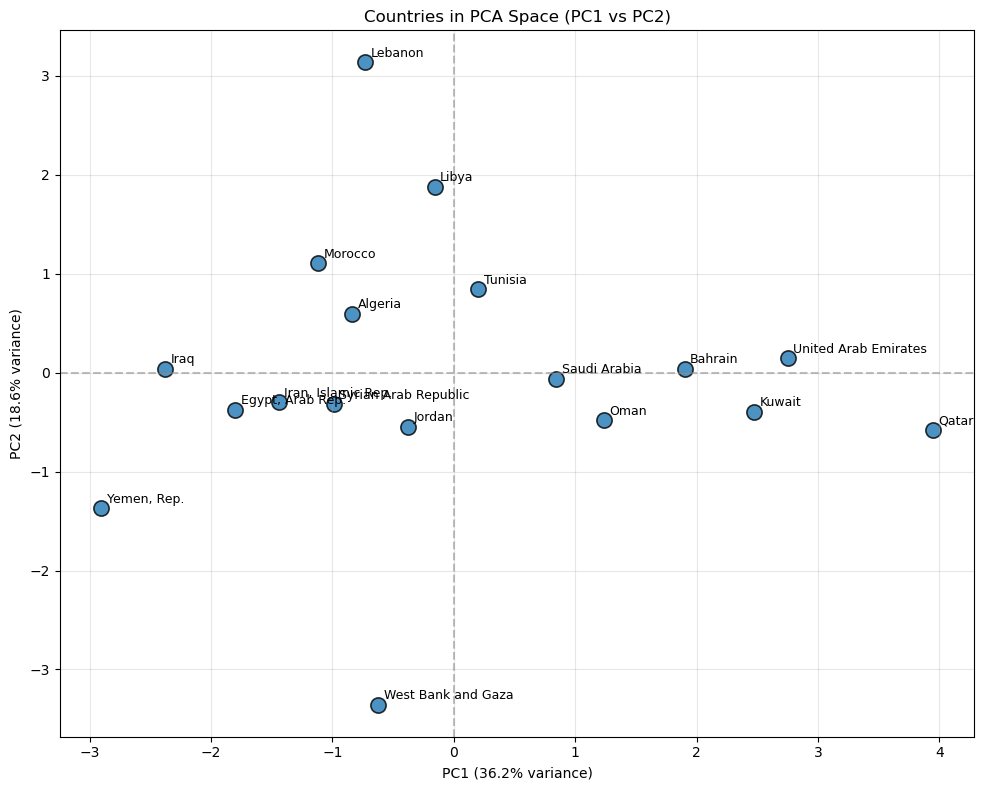

In [33]:
plt.figure(figsize=(10, 8))

regions = pca_df["region"] if "region" in pca_df.columns else None

if regions is not None:
    region_colors = {
        "GCC": "#E74C3C",
        "Levant": "#3498DB",
        "North Africa": "#2ECC71",
        "Other": "#F39C12"
    }
    
    for region, color in region_colors.items():
        mask = regions == region
        if mask.sum() > 0:
            plt.scatter(
                pca_df.loc[mask, "PC1"],
                pca_df.loc[mask, "PC2"],
                label=region,
                s=120,
                alpha=0.8,
                edgecolors="black",
                linewidth=1.2,
            )
else:
    plt.scatter(pca_df["PC1"], pca_df["PC2"], s=120, alpha=0.8, edgecolors="black", linewidth=1.2)

# annotate country names
for country in pca_df.index:
    plt.annotate(
        country,
        (pca_df.loc[country, "PC1"], pca_df.loc[country, "PC2"]),
        fontsize=9,
        xytext=(4, 4),
        textcoords="offset points"
    )

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)

plt.xlabel(f"PC1 ({var1:.1f}% variance)")
plt.ylabel(f"PC2 ({var2:.1f}% variance)")
plt.title("Countries in PCA Space (PC1 vs PC2)")
plt.grid(alpha=0.3)
if regions is not None:
    plt.legend()
plt.tight_layout()
plt.show()


In [34]:
ml_df.head()

,"Population, total_mean",GDP per capita (current US$)_mean,"School enrollment, secondary (gross), gender parity index (GPI)_mean",Proportion of seats held by women in national parliaments (%)_mean,Women Business and the Law Index Score (scale 1-100)_mean,"Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean","Adolescent fertility rate (births per 1,000 women ages 15-19)_mean","Inflation, consumer prices (annual %)_mean","Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean"
country_name,,,,,,,,,
Algeria,4.122578e+07,4991.221498,1.038538,21.485630,56.428571,77.857143,9.756929,5.337271,11.726714
Bahrain,1.397187e+06,25991.901821,1.040759,11.607143,44.196429,14.857143,12.226643,1.271203,41.151929
"Egypt, Arab Rep.",1.022794e+08,3117.834388,0.986903,15.138855,43.973214,26.142857,50.559214,13.004708,15.489214
"Iran, Islamic Rep.",8.414512e+07,5369.001800,0.959292,4.559862,30.535714,24.785714,32.936214,26.042604,11.937571
Iraq,3.856081e+07,5436.911634,198240.020355,26.306004,40.357143,83.357143,72.327214,1.444095,9.307714


In [47]:
ml_df.to_csv("data/ml_dataset.csv", index=False)

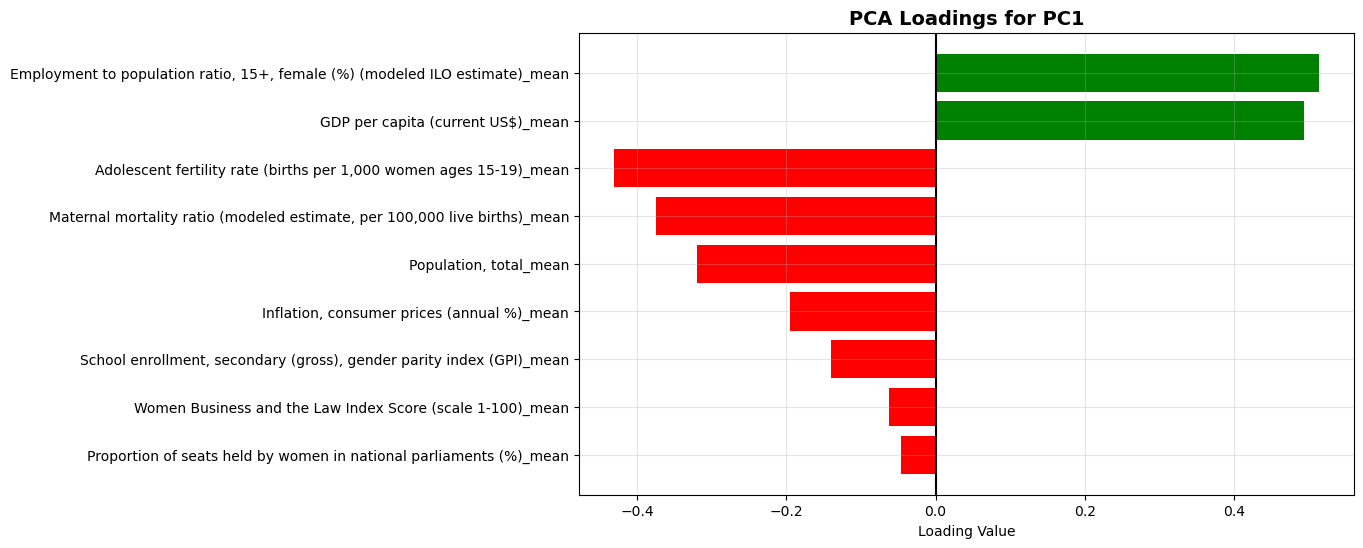

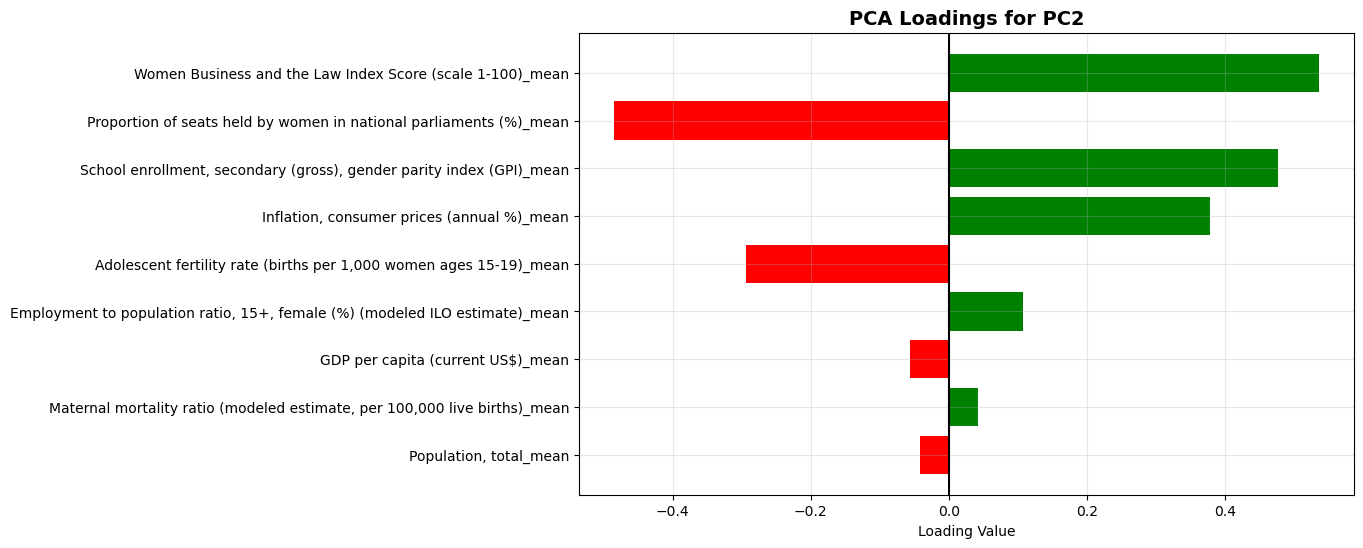

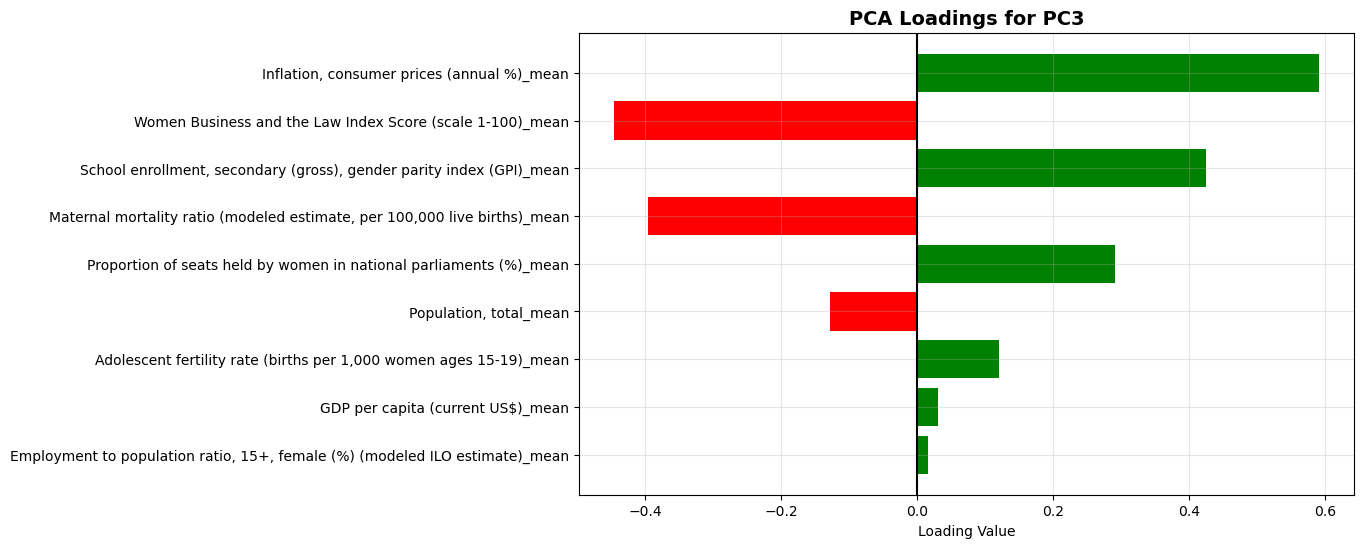

In [48]:
# ============================
# PCA Loadings Plot
# ============================

def plot_loadings(pca, features, pc_index=0, top_n=10):
    """
    pc_index: 0 = PC1, 1 = PC2, 2 = PC3, etc.
    """
    loadings = pca.components_[pc_index]
    loading_df = pd.DataFrame({
        "Feature": features,
        "Loading": loadings,
        "Abs_Loading": np.abs(loadings)
    }).sort_values("Abs_Loading", ascending=False).head(top_n)

    plt.figure(figsize=(10,6))
    colors = ["green" if v > 0 else "red" for v in loading_df["Loading"]]

    plt.barh(loading_df["Feature"], loading_df["Loading"], color=colors)
    plt.title(f"PCA Loadings for PC{pc_index+1}", fontsize=14, fontweight="bold")
    plt.xlabel("Loading Value")
    plt.axvline(0, color="black")
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.show()

# Plot for the first 3 PCs
plot_loadings(pca, ml_features, pc_index=0, top_n=10)
plot_loadings(pca, ml_features, pc_index=1, top_n=10)
plot_loadings(pca, ml_features, pc_index=2, top_n=10)
